Basis: 11 factors + target (ICICI_Close)
Rows after dropping NA across basis: 4253 / 4253

--- ADF test on each series (level) ---
series                            ADF stat   p-value  verdict
Trade_Balance_Billion_USD           -2.729    0.0692  non-stationary (I(1)-like) — OK for Johansen
WPI_Index                           -1.200    0.6735  non-stationary (I(1)-like) — OK for Johansen
NII (₹ Cr)                           1.420    0.9972  non-stationary (I(1)-like) — OK for Johansen
Repo_Rate_%                         -1.904    0.3300  non-stationary (I(1)-like) — OK for Johansen
CRR_%                               -1.576    0.4956  non-stationary (I(1)-like) — OK for Johansen
FII_Net                             -3.119    0.0252  STATIONARY already (I(0)) — check if it belongs here
DII_Net                             -3.463    0.0090  STATIONARY already (I(0)) — check if it belongs here
Gold_Close                           3.229    1.0000  non-stationary (I(1)-like) — OK for Johansen

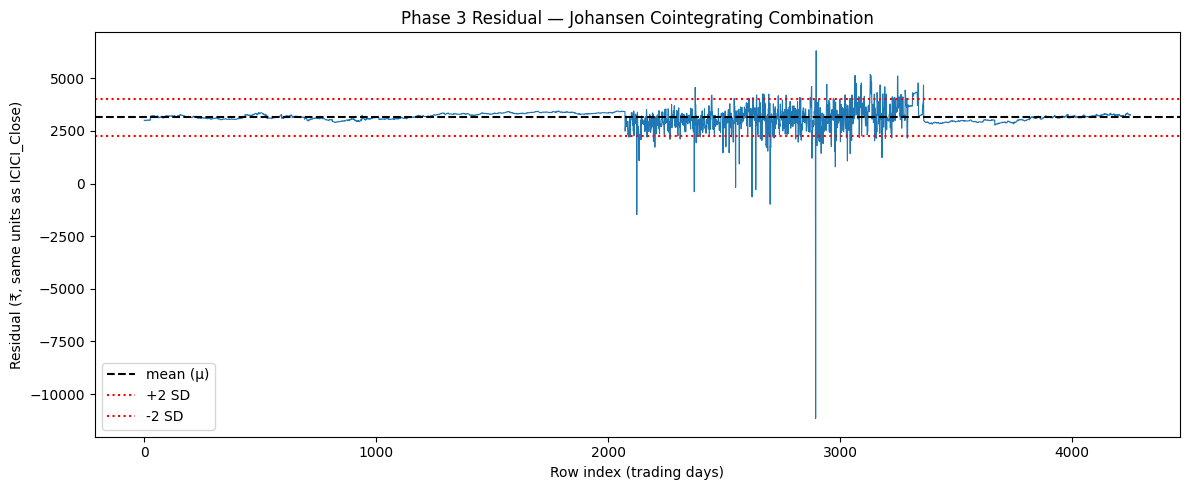

In [1]:
"""
QOIN — Phase 3: Linear Transformation Spine
Johansen Cointegration Test

Purpose: find the single linear combination of factors + ICICI_Close that is
stationary. The Johansen eigenvector IS the weight vector (w1, w2, ...) AND
the residual it produces is the mean-reverting series (the "hollow sphere").
This one test replaces doing OLS-then-separately-checking-stationarity.

Run locally: python phase3_johansen.py
"""

import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.vecm import coint_johansen
import matplotlib.pyplot as plt

# ============================================================
# CONFIG — adjust paths/column names here if they don't match your CSV
# ============================================================
DATA_PATH = "/Users/surisettivamsikrishna/Downloads/Vamsi Pc/CODES/Qoin/Model data/master_aligned_fixed.csv"
DATE_COL = None  # set to the exact date column name if auto-detect fails

# Final Phase 3 basis — decided from dendrogram cut at distance=0.3 (|corr|=0.70)
# Excluded on purpose:
#   - Nifty_Close, BankNifty_Close: ICICI is a constituent of both -> mechanical, not causal
#   - ICICI_RSI_14, Nifty_RSI_14, BankNifty_RSI_14: derived FROM price -> circular
#   - CPI_Index (kept WPI_Index instead — reacts faster)
#   - Net_Profit (kept NII instead — core banking earnings driver, less accounting discretion)
#   - Real_GDP_YoY_Growth_%: dropped to fit statsmodels' 12-variable Johansen limit
#     (12 factors + target = 13, one over). GDP is quarterly and forward-filled to
#     daily, so it was the lowest-frequency, most "stair-stepped" input anyway —
#     weakest daily signal of the 12. Swap this back in for something else if you
#     disagree with the cut.
SINGLETON_FACTORS = [
    "Trade_Balance_Billion_USD",
    "WPI_Index",
    "NII (₹ Cr)",
    "Repo_Rate_%",
    "CRR_%",
    "FII_Net",
    "DII_Net",
    "Gold_Close",
    "USD_INR",
]

# (new_column_name, long_maturity_col, short_maturity_col)
YIELD_SPREADS = [
    ("US_Yield_Spread", "US_10Y", "US_5Y"),
    ("IN_Yield_Spread", "Bond_10Y", "Bond_5Y"),
]

TARGET_COL = "ICICI_Close"


# ============================================================
# STEP 1 — Load and build the basis
# ============================================================
def load_and_prepare(path):
    df = pd.read_csv(path)

    date_col = DATE_COL or df.columns[0]
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col).reset_index(drop=True)

    for spread_name, long_col, short_col in YIELD_SPREADS:
        if long_col not in df.columns or short_col not in df.columns:
            raise ValueError(
                f"Cannot build {spread_name}: missing '{long_col}' or '{short_col}'. "
                f"Available columns: {df.columns.tolist()}"
            )
        df[spread_name] = df[long_col] - df[short_col]

    basis_cols = SINGLETON_FACTORS + [name for name, _, _ in YIELD_SPREADS]
    all_cols = basis_cols + [TARGET_COL]

    missing = [c for c in all_cols if c not in df.columns]
    if missing:
        raise ValueError(
            f"Missing columns: {missing}\nAvailable columns: {df.columns.tolist()}"
        )

    sub = df[all_cols].dropna().reset_index(drop=True)
    print(f"Basis: {len(basis_cols)} factors + target ({TARGET_COL})")
    print(f"Rows after dropping NA across basis: {len(sub)} / {len(df)}\n")
    return sub


# ============================================================
# STEP 2 — Confirm each series is non-stationary in levels (I(1))
# Johansen assumes this. If something is already stationary on its own,
# it shouldn't need cointegration to explain it — flag it, don't ignore it.
# ============================================================
def check_integration_order(df):
    print("--- ADF test on each series (level) ---")
    print(f"{'series':30s}  {'ADF stat':>10s}  {'p-value':>8s}  verdict")
    for col in df.columns:
        stat, pval, *_ = adfuller(df[col], autolag="AIC")
        verdict = "STATIONARY already (I(0)) — check if it belongs here" if pval < 0.05 else "non-stationary (I(1)-like) — OK for Johansen"
        print(f"{col:30s}  {stat:10.3f}  {pval:8.4f}  {verdict}")
    print()


# ============================================================
# STEP 3 — Johansen test: produces weights + stationary residual together
# det_order=0: assume the cointegrating relationship reverts to a constant
#   mean, not a trending one (matches the "hollow sphere has a fixed center"
#   picture). k_ar_diff=1: one lagged difference in the underlying VECM —
#   a simplification; revisit with proper lag-order selection later.
# ============================================================
def run_johansen(df, det_order=0, k_ar_diff=1):
    print("--- Johansen Cointegration Test ---")
    result = coint_johansen(df.values, det_order, k_ar_diff)

    trace_stat = result.lr1
    trace_crit_95 = result.cvt[:, 1]

    print(f"{'hypothesis':>12s}  {'trace stat':>10s}  {'95% crit':>10s}  verdict")
    rank = 0
    for i in range(len(trace_stat)):
        significant = trace_stat[i] > trace_crit_95[i]
        verdict = "REJECT null -> cointegration exists" if significant else "fail to reject"
        print(f"{'r <= ' + str(i):>12s}  {trace_stat[i]:10.3f}  {trace_crit_95[i]:10.3f}  {verdict}")
        if significant:
            rank = i + 1
    print(f"\nEstimated cointegration rank: {rank}")
    if len(df.columns) >= 12:
        print("Note: 12+ variable Johansen systems get statistically noisy on ~4000 rows. "
              "A rank of 0 here doesn't rule out a smaller subset cointegrating — "
              "worth re-testing on a pruned basis if this comes back empty.\n")
    else:
        print()
    return result, rank


# ============================================================
# STEP 4 — Extract weights + residual from the strongest eigenvector,
# rescaled so ICICI_Close's own coefficient is 1:
#   ICICI_Close ≈ Σ w_i · factor_i + residual
# ============================================================
def build_residual(df, result, target_col):
    evec = result.evec[:, 0]  # eigenvector for the largest eigenvalue = strongest relation
    target_idx = df.columns.get_loc(target_col)
    scale = evec[target_idx]

    weights = -evec / scale
    raw_combo = df.values @ evec
    residual = pd.Series(raw_combo / scale, name="residual")

    print("--- Weight vector: ICICI_Close ≈ Σ w_i · factor_i + residual ---")
    for col, w in zip(df.columns, weights):
        if col != target_col:
            print(f"  {col:30s}  {w: .5f}")
    print()
    return residual, weights


# ============================================================
# STEP 5 — ADF on the residual itself. This is the pass/fail gate.
# ============================================================
def adf_on_residual(residual):
    stat, pval, *_ = adfuller(residual, autolag="AIC")
    print("--- ADF test on residual ---")
    if pval < 0.05:
        print(f"ADF stat={stat:.3f}  p={pval:.4f}  STATIONARY.")
        print("Cointegration confirmed on this basis. The weights above are real, "
              "and this residual is the OU-fittable mean-reverting series.")
    else:
        print(f"ADF stat={stat:.3f}  p={pval:.4f}  NOT stationary.")
        print("This basis does not cointegrate at 95% confidence. Do not fit OU on "
              "this residual or trust these weights — they're a spurious fit.")
    print()
    return stat, pval


def plot_residual(residual, path="phase3_residual.png"):
    mu = residual.mean()
    sd = residual.std()

    plt.figure(figsize=(12, 5))
    plt.plot(residual.values, linewidth=0.8)
    plt.axhline(mu, color="black", linestyle="--", label="mean (μ)")
    plt.axhline(mu + 2 * sd, color="red", linestyle=":", label="+2 SD")
    plt.axhline(mu - 2 * sd, color="red", linestyle=":", label="-2 SD")
    plt.title("Phase 3 Residual — Johansen Cointegrating Combination")
    plt.xlabel("Row index (trading days)")
    plt.ylabel("Residual (₹, same units as ICICI_Close)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    print(f"Saved residual plot to {path}")


if __name__ == "__main__":
    df = load_and_prepare(DATA_PATH)
    check_integration_order(df)
    result, rank = run_johansen(df)

    if rank == 0:
        print("No cointegration found at 95% confidence on the full 12-factor basis.")
        print("Do not proceed to OU fitting yet — try pruning to a smaller subset "
              "(e.g. drop the weakest macro factors) and re-run.")
    else:
        residual, weights = build_residual(df, result, TARGET_COL)
        adf_on_residual(residual)
        plot_residual(residual)